In [2]:
#1. FOR XGB

In [3]:
#1.a XGB_WithMeteo

In [1]:
import pandas as pd
import numpy as np

aug_factor = 3 #augmented has been done initially for aug_factor = 2, then for aug_factor = 3

doc_train_augmented = pd.read_csv (f"D:\Shukra_sir\MLAllTraining\ForTraining\TrainableWithBandRatios\AugmentedWithBR\DOC_AUG_WITH_BR\DOCWithBR_TRAIN_AUG{aug_factor}.csv")
doc_test = pd.read_csv(f"D:\Shukra_sir\MLAllTraining\ForTraining\TrainableWithBandRatios\AugmentedWithBR\DOC_AUG_WITH_BR\DOCWithBR_TEST_AUG{aug_factor}.csv")

doc_train_augmented.shape, doc_test.shape

((2732, 55), (171, 55))

In [2]:
doc_train_augmented ['result_DOC_log'] = np.log1p (doc_train_augmented ['result_DOC'])
doc_test ['result_DOC_log'] = np.log1p (doc_test ['result_DOC'])
doc_train_augmented

,Unnamed: 0,sample_date,B1,B11,B12,B2,B3,B4,B5,B6,...,B3_div_B2,ND_B4_B3,ND_B2_B3,ND_B6_B8,day_of_year,doy_sin,doy_cos,hour_sin,hour_cos,result_DOC_log
0,0,2024-05-08 14:00:00,0.037800,0.168600,0.105100,0.040100,0.063600,0.050700,0.094400,0.220200,...,1.585995,-0.112860,-0.226613,-0.130503,129,0.796183,-0.605056,-0.500000,-0.866025,0.741937
1,1,2019-08-20 15:00:00,0.068100,0.144400,0.130300,0.057300,0.075900,0.073100,0.098200,0.105800,...,1.324584,-0.018792,-0.139639,0.109596,232,-0.752667,-0.658402,-0.707107,-0.707107,1.308333
2,2,2022-02-01 20:55:00,0.015100,0.165100,0.131400,0.033200,0.053800,0.056300,0.095100,0.146200,...,1.620433,0.022706,-0.236779,-0.071156,32,0.523416,0.852078,-0.866025,0.500000,0.741937
3,3,2018-11-06 21:25:00,0.007100,0.026500,0.019000,0.019100,0.030400,0.022600,0.023400,0.014200,...,1.591540,-0.147167,-0.228278,-0.080904,310,-0.811539,0.584298,-0.707107,0.707107,1.481605
4,4,2018-11-06 19:20:00,0.001400,0.010400,0.010300,0.013300,0.020300,0.008900,0.006200,0.000000,...,1.526201,-0.390398,-0.208327,0.000000,310,-0.811539,0.584298,-0.965926,0.258819,1.193922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2727,2727,2019-08-20 16:00:00,0.160048,0.347841,0.301870,0.194634,0.206942,0.225023,0.253643,0.254485,...,1.063231,0.041857,-0.030649,-0.043629,232,-0.752667,-0.658402,-0.866025,-0.500000,1.536867
2728,2728,2021-08-17 15:45:00,0.106466,0.173790,0.156926,0.132880,0.156900,0.169819,0.182550,0.194755,...,1.180757,0.039542,-0.082891,0.040882,229,-0.717677,-0.696376,-0.707107,-0.707107,1.547563
2729,2729,2023-05-24 17:43:00,0.041518,0.115512,0.094602,0.046671,0.063934,0.065133,0.090442,0.112315,...,1.369847,0.009291,-0.156073,-0.035528,144,0.615285,-0.788305,-0.965926,-0.258819,1.410987
2730,2730,2018-06-19 19:24:00,0.051536,0.046751,0.038356,0.069572,0.074987,0.053739,0.051703,0.041847,...,1.077817,-0.165069,-0.037458,-0.020389,170,0.213521,-0.976938,-0.965926,0.258819,1.029619


In [3]:
TARGET = "result_DOC_log" #FOR DOC
TARGET1 = "result_DOC"

input_features = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 
                'B9',
               "B4_minus_B3",
               "B4_div_B3", 
               "ND_B4_B3", 
               'Temperature', 'DewPoint', 'v10n', 
               'doy_sin', 'doy_cos', 
               'latitude', 'longitude'
               ]

X_train = doc_train_augmented[input_features]
y_train = doc_train_augmented[TARGET]

X_test = doc_test[input_features]
y_test = doc_test[TARGET]

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((2732, 19), (2732,), (171, 19), (171,))

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

#Checking version of xgboost
print("XGBoost version:", xgb.__version__)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

XGBoost version: 3.1.2


In [5]:
#Best_Params as per hyperParam Tuning

best_params =  {'n_estimators': 1578, 'max_depth': 5, 'learning_rate': 0.07530958220937786, 'min_child_weight': 5, 'subsample': 0.6636151981679363, 'colsample_bytree': 0.8293060052837359, 'reg_lambda': 2.409308901879787, 'reg_alpha': 0.33529031476388216}
print(best_params)

{'n_estimators': 1578, 'max_depth': 5, 'learning_rate': 0.07530958220937786, 'min_child_weight': 5, 'subsample': 0.6636151981679363, 'colsample_bytree': 0.8293060052837359, 'reg_lambda': 2.409308901879787, 'reg_alpha': 0.33529031476388216}


In [9]:
#Eval Metrics AfterHyparamTuning _WithMeteo


"""
Final R² (log scale): 0.7083042378380461
Final R² (real scale): 0.6559290615878791
R² for DOC on normal: 0.6559290615878791
Final metrics on NORMAL scale (after inverse log):
R²   : 0.6559
MSE  : 1.0730
RMSE : 1.0358
MAE  : 0.6331
"""

'\nFinal R² (log scale): 0.7083042378380461\nFinal R² (real scale): 0.6559290615878791\nR² for DOC on normal: 0.6559290615878791\nFinal metrics on NORMAL scale (after inverse log):\nR²   : 0.6559\nMSE  : 1.0730\nRMSE : 1.0358\nMAE  : 0.6331\n'

In [6]:
# 4️⃣ Train final model on all augmented train data with best params
# --------------------------
#best_params = study.best_params
final_model = XGBRegressor(
    **best_params,
    tree_method="hist",
    device="cuda",
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

y_pred_log = final_model.predict(X_test_scaled)

import numpy as np
from sklearn.metrics import r2_score

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print("Final R² (log scale):", r2_score(y_test, y_pred_log))
print("Final R² (real scale):", r2_score(y_test_real, y_pred_real))


# Back-transform predictions and true values
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)
print("R² for DOC on normal:", r2_score(y_test_real, y_pred_real))

# ---- Metrics on normal scale ----
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)

print("Final metrics on NORMAL scale (after inverse log):")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")



Final R² (log scale): 0.7083042378380461
Final R² (real scale): 0.6559290615878791
R² for DOC on normal: 0.6559290615878791
Final metrics on NORMAL scale (after inverse log):
R²   : 0.6559
MSE  : 1.0730
RMSE : 1.0358
MAE  : 0.6331


d:\Miniconda3\envs\PyTorchVirtualEnv\Lib\site-packages\xgboost\core.py:750: UserWarning: [09:18:26] WARNING: D:\bld\xgboost-split_1765326833453\work\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [7]:
# 4️⃣ Train final model on all augmented train data with best params
# --------------------------
#best_params = study.best_params
final_model = XGBRegressor(
    **best_params,
    tree_method="hist",
    device="cuda",
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

y_pred_log = final_model.predict(X_test_scaled)

import numpy as np
from sklearn.metrics import r2_score

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print("Final R² (log scale):", r2_score(y_test, y_pred_log))
print("Final R² (real scale):", r2_score(y_test_real, y_pred_real))


# Back-transform predictions and true values
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)
print("R² for DOC on normal:", r2_score(y_test_real, y_pred_real))

# ---- Metrics on normal scale ----
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)

print("Final metrics on NORMAL scale (after inverse log):")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


Final R² (log scale): 0.7083042378380461
Final R² (real scale): 0.6559290615878791
R² for DOC on normal: 0.6559290615878791
Final metrics on NORMAL scale (after inverse log):
R²   : 0.6559
MSE  : 1.0730
RMSE : 1.0358
MAE  : 0.6331


In [ ]:
#Graph 

In [8]:
#Graph for Predicted vs Actual
import matplotlib.pyplot as plt



In [10]:
final_model_Graph_WM = XGBRegressor(
    tree_method="hist",
    device="cuda",  # remove if using CPU
    objective="reg:squarederror",
    random_state=42,
    **best_params
)

final_model_Graph_WM.fit(X_train_scaled, y_train)

y_pred_log = final_model_Graph_WM.predict(X_test_scaled)

y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

r2_log = r2_score(y_test, y_pred_log)

print("Final R² (log scale):", r2_score(y_test, y_pred_log))
print("Final R² (real scale):", r2_score(y_test_real, y_pred_real))

# Back-transform predictions and true values
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)
print("R² for DOC on normal:", r2_score(y_test_real, y_pred_real))

# ---- Metrics on normal scale ----
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)

print("Final metrics on NORMAL scale (after inverse log):")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


Final R² (log scale): 0.7083042378380461
Final R² (real scale): 0.6559290615878791
R² for DOC on normal: 0.6559290615878791
Final metrics on NORMAL scale (after inverse log):
R²   : 0.6559
MSE  : 1.0730
RMSE : 1.0358
MAE  : 0.6331


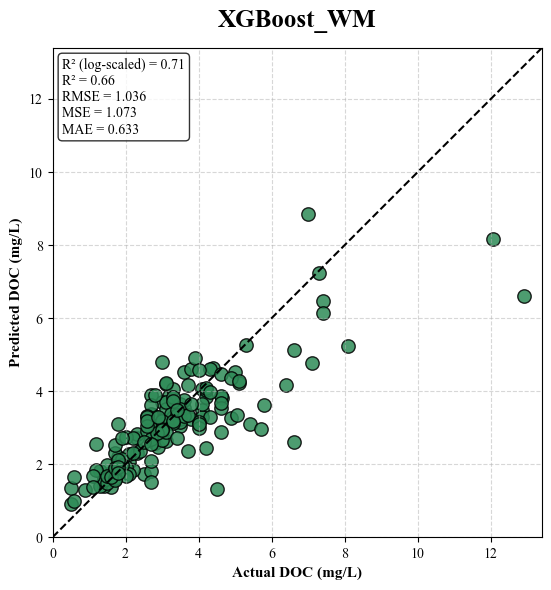

In [9]:
plt.figure(figsize=(6,6))

# Scatter plot

plt.rcParams["font.family"] = "Times New Roman"

"""
Font Name	When to Use
Times New Roman	Most journals, thesis (very safe choice)
Arial	Clean, modern journals
Helvetica	Very professional (if installed)
Calibri	Thesis (Word consistency)
Computer Modern	If matching LaTeX paper
"""


plt.scatter(y_test_real, y_pred_real, s=93, edgecolor='black', color='#2e8b57', alpha=0.85)  #syntax: plt.scatter(x, y)
plt.title("XGBoost_WM", fontsize=18, fontweight='bold', pad=15)

# 1:1 line
min_val = min(min(y_test_real), min(y_pred_real))
max_val = max(max(y_test_real), max(y_pred_real))
plt.plot([0, max_val+0.5], [0, max_val+0.5], 'k--', 
        #linewidth=1
        )

# Labels
plt.xlabel("Actual DOC (mg/L)", fontsize=11, fontweight='bold')
plt.ylabel("Predicted DOC (mg/L)", fontsize=11, fontweight='bold')

# Make square
plt.gca().set_aspect('equal', adjustable='box')

# REMOVE automatic padding
plt.margins(0)

metrics_text = (
    f"R² (log-scaled) = {r2_log:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"MSE = {mse:.3f}\n"
    f"MAE = {mae:.3f}"
)

plt.text(
    #0.98, 0.98, #for right
    0.02, 0.98, #move to left

    metrics_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',

    #horizontalalignment='right', #for right
    horizontalalignment='left',  #for left
    
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

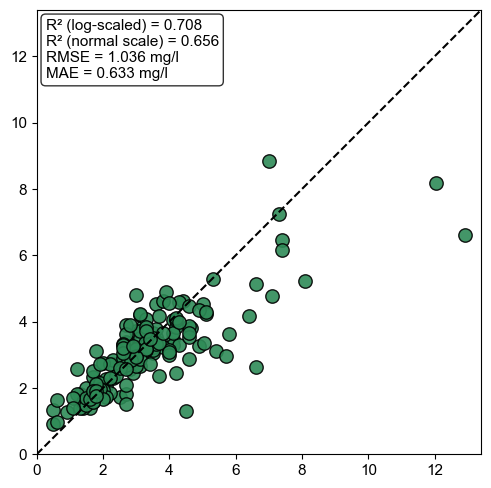

In [11]:
#Without titles
import os
plt.figure(figsize=(5,5))

# Scatter plot

plt.rcParams["font.family"] = "Arial"

plt.scatter(y_test_real, y_pred_real, s=93, edgecolor='black', color='#2e8b57', alpha=0.9)  #syntax: plt.scatter(x, y)


# 1:1 line
min_val = min(min(y_test_real), min(y_pred_real))
max_val = max(max(y_test_real), max(y_pred_real))
plt.plot([0, max_val+0.5], [0, max_val+0.5], 'k--')

# Make square
plt.gca().set_aspect('equal', adjustable='box')

# REMOVE automatic padding
plt.margins(0)


metrics_text = (
    f"R² (log-scaled) = {r2_log:.3f}\n"
    f"R² (normal scale) = {r2:.3f}\n"
    f"RMSE = {rmse:.3f} mg/l\n"
    #f"MSE = {mse:.3f}\n"
    f"MAE = {mae:.3f} mg/l"
)
# Labels
#plt.xlabel("Actual DOC (mg/l as C)", fontsize=8, fontweight='bold')
#plt.ylabel("Predicted DOC (mg/l as C)", fontsize=8, fontweight='bold')

plt.text(
    0.02, 0.98, #move to left
    metrics_text,
    fontsize = 11,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='left',  #for left
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
# --- Save with high resolution ---
save_dir = r"D:\Shukra_sir\Manuscript for ACS\Version 2_with ACS citations\UpdatedGraphsWithArial\PredictedVsActual\SavedGraphswithoutGradientWithArial"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "WM_XGB.jpeg")

plt.savefig(save_path, dpi=1200, bbox_inches='tight')  # 600 dpi, publication quality
plt.show()

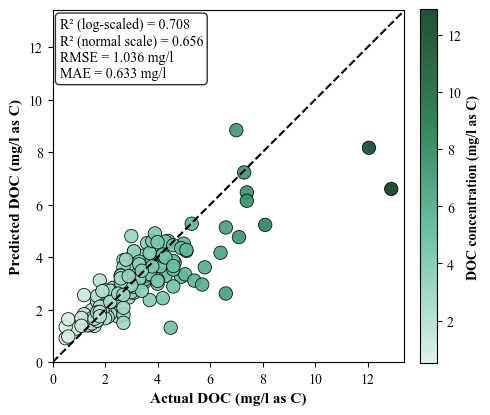

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# Without titles
plt.figure(figsize=(5,5))
plt.rcParams["font.family"] = "Times New Roman"

# --- Gradient scatter ---
# Color by concentration value (use y_test_real as the "true" concentration driving the gradient)
# You can swap to (y_test_real + y_pred_real)/2 if you want the gradient to reflect both

# Custom green colormap: light green (low) -> dark forest green (high)
green_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_green", ["#d9f2e6", "#66c2a5", "#1b7a4d", "#0b3d20"]
)

sc = plt.scatter(
    y_test_real, y_pred_real,
    c=y_test_real,              # value driving the gradient
    cmap=green_cmap,
    s=93,
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

# Colorbar to show the gradient scale
cbar = plt.colorbar(sc, fraction=0.046, pad=0.04)
cbar.set_label("DOC concentration (mg/l as C)", fontsize=10, fontweight='bold')

# 1:1 line
min_val = min(min(y_test_real), min(y_pred_real))
max_val = max(max(y_test_real), max(y_pred_real))
plt.plot([0, max_val+0.5], [0, max_val+0.5], 'k--')

# Make square
plt.gca().set_aspect('equal', adjustable='box')

# Remove automatic padding
plt.margins(0)

metrics_text = (
    f"R² (log-scaled) = {r2_log:.3f}\n"
    f"R² (normal scale) = {r2:.3f}\n"
    f"RMSE = {rmse:.3f} mg/l\n"
    f"MAE = {mae:.3f} mg/l"
)

# Labels
plt.xlabel("Actual DOC (mg/l as C)", fontsize=11, fontweight='bold')
plt.ylabel("Predicted DOC (mg/l as C)", fontsize=11, fontweight='bold')

plt.text(
    0.02, 0.98,
    metrics_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()

# --- Save with high resolution ---
save_dir = r"D:\Shukra_sir\Manuscript for ACS\Version 1\UpdatedGraphs\PredictedVsActual\SavedGraphswithGradient"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "WM_XGB.jpeg")

plt.savefig(save_path, dpi=600, bbox_inches='tight')  # 600 dpi, publication quality
plt.show()

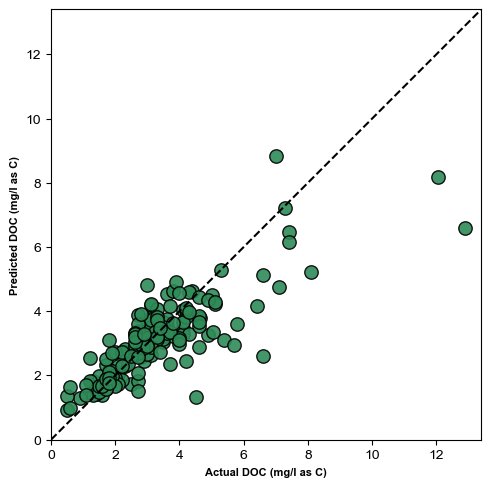

In [12]:
#Without titles
import os
plt.figure(figsize=(5,5))

# Scatter plot

plt.rcParams["font.family"] = "Arial"

plt.scatter(y_test_real, y_pred_real, s=93, edgecolor='black', color='#2e8b57', alpha=0.9)  #syntax: plt.scatter(x, y)


# 1:1 line
min_val = min(min(y_test_real), min(y_pred_real))
max_val = max(max(y_test_real), max(y_pred_real))
plt.plot([0, max_val+0.5], [0, max_val+0.5], 'k--')

# Make square
plt.gca().set_aspect('equal', adjustable='box')

# REMOVE automatic padding
plt.margins(0)


metrics_text = (
    f"R² (log-scaled) = {r2_log:.3f}\n"
    f"R² (normal scale) = {r2:.3f}\n"
    f"RMSE = {rmse:.3f} mg/l\n"
    #f"MSE = {mse:.3f}\n"
    f"MAE = {mae:.3f} mg/l"
)
# Labels
plt.xlabel("Actual DOC (mg/l as C)", fontsize=8, fontweight='bold')
plt.ylabel("Predicted DOC (mg/l as C)", fontsize=8, fontweight='bold')

#plt.text(
#    0.02, 0.98, #move to left
#    metrics_text,
#    fontsize = 8,
#    transform=plt.gca().transAxes,
#    verticalalignment='top',
#    horizontalalignment='left',  #for left
#    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
#)

plt.tight_layout()
# --- Save with high resolution ---
save_dir = r"D:\Shukra_sir\Manuscript for ACS\Version 2_with ACS citations\UpdatedGraphsWithArial\PredictedVsActual\SavedGraphswithoutGradientWithArial"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "Graph to be added in Graphical abstract.jpeg")

plt.savefig(save_path, dpi=600, bbox_inches='tight')  # 600 dpi, publication quality
plt.show()